## 1. Import Library yang Dibutuhkan
Di sini kita memuat pustaka analisis data, visualisasi, dan machine learning.


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer


## 2. Memuat dan Mempersiapkan Data
Kita memuat dataset `IGRS_DATASET_UPDATED2.csv`, menghapus baris duplikat, dan menstandarkan label sentimen.


In [ ]:
# Load Dataset
df = pd.read_csv('IGRS_DATASET_UPDATED2.csv')

# Menghapus baris yang nilai 'status' atau 'full_text'-nya kosong
df = df.dropna(subset=['status', 'full_text'])

# Menghapus data duplikat (Gabungan dari langkah data preparation sebelumnya)
df = df.drop_duplicates(subset=['full_text'])

# Menyeragamkan penulisan label status
df['status'] = df['status'].replace({'netrlal': 'netral', 'negatiff': 'negatif'})

# Mapping label teks menjadi angka (0: negatif, 1: netral, 2: positif)
label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label'] = df['status'].map(label_map)

# Menghapus jika ada label yang tidak dikenali
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Menampilkan 5 data teratas
df.head()


,status,full_text,id_str,label
0,netral,Gila banget uni Sofie lulusan Goldsmith ngata2...,2041776274432258107,1
1,negatif,Udah sok tau dongo lagi gak bisa baca. Jelas-j...,2041775922001670443,0
2,negatif,Indonesia tuh gak akan ada berhentinya lucu ab...,2041775913076191566,0
3,netral,IGRS udah dibahas channel gaming di Youtube ka...,2041775653599768876,1
4,negatif,@Bram_no3 @sanggarrrr @23compiled @ero_semut @...,2041774824822124771,0


## 3. Visualisasi Data (Pie Chart)
Mari kita lihat sebaran awal data (sebelum dioversampling) berdasarkan sentimen (Negatif, Netral, Positif).


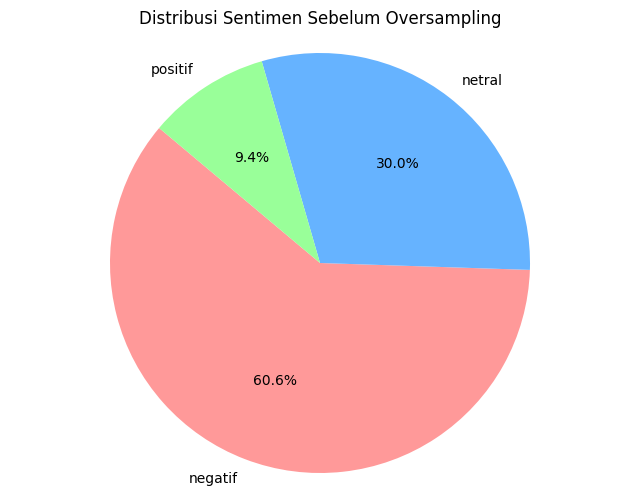

In [ ]:
# Menghitung jumlah masing-masing sentimen
sentiment_counts = df['status'].value_counts()

# Membuat diagram lingkaran (Pie Chart)
plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribusi Sentimen Sebelum Oversampling')
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
plt.show()


## 4. Pembersihan Teks (Text Preprocessing)
Membersihkan teks dengan mengubah huruf menjadi huruf kecil, menghapus URL, mention, hashtag, karakter khusus, dan spasi berlebih.\n
*Optimalisasi:* Menggunakan kompilasi regex (`re.compile`) agar proses lebih cepat.


In [ ]:
# Kompilasi pola RegEx untuk performa yang lebih baik
url_pattern = re.compile(r'http\S+|www\S+|https\S+', flags=re.MULTILINE)
mention_pattern = re.compile(r'\@\w+')
hashtag_pattern = re.compile(r'\#\w+')
special_char_pattern = re.compile(r'[^a-z\s]')
whitespace_pattern = re.compile(r'\s+')

def bersihkan_teks(text):
    text = str(text).lower()
    text = url_pattern.sub('', text)
    text = mention_pattern.sub('', text)
    text = hashtag_pattern.sub('', text)
    text = special_char_pattern.sub(' ', text)
    text = whitespace_pattern.sub(' ', text).strip()
    return text

# Menerapkan pembersihan teks
df['full_text'] = df['full_text'].apply(bersihkan_teks)


## 5. Train-Test Split dan Oversampling
Kita bagi dataset menjadi data latih dan uji, kemudian lakukan *RandomOverSampler* pada data latih untuk menyeimbangkan kelas yang minoritas.


In [ ]:
# Lakukan split terlebih dahulu untuk mencegah Data Leakage
train_df, test_df = train_test_split(df[['full_text', 'label']], test_size=0.2, random_state=42, stratify=df['label'])

print("Distribusi Data Training SEBELUM Oversampling:")
print(train_df['label'].value_counts())

# Menginisialisasi RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Mengambil indeks untuk oversampling
train_indices = train_df.index.to_numpy().reshape(-1, 1)

# Oversampling berdasarkan indeks
indices_resampled, _ = ros.fit_resample(train_indices, train_df['label'])

# Membuat dataframe training baru dari indeks hasil oversampling
train_df_balanced = train_df.loc[indices_resampled.flatten()].reset_index(drop=True)

print("\nDistribusi Data Training SETELAH Oversampling:")
print(train_df_balanced['label'].value_counts())

# Membuat format Dataset dari HuggingFace
train_dataset = Dataset.from_pandas(train_df_balanced, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)


Distribusi Data Training SEBELUM Oversampling:
label
0    82
1    41
2    13
Name: count, dtype: int64

Distribusi Data Training SETELAH Oversampling:
label
0    82
1    82
2    82
Name: count, dtype: int64


## 6. Tokenisasi
Kita mengubah teks menjadi format yang dimengerti model IndoBERT (`indolem/indobert-base-uncased`).


In [ ]:
model_name = "indolem/indobert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["full_text"], padding="max_length", truncation=True, max_length=128)

# Menerapkan tokenisasi
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Mengubah ke format Tensor PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/246 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

## 7. Setup dan Pelatihan Model
Menginisialisasi model `AutoModelForSequenceClassification` serta mengkonfigurasi parameter training menggunakan `Trainer`.


In [ ]:
id2label = {0: "negatif", 1: "netral", 2: "positif"}
label2id = {"negatif": 0, "netral": 1, "positif": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# Konfigurasi Training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=12,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=20,
    logging_dir='./logs',
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

# Memulai pelatihan model
trainer.train()


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecat

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.014851,0.945694,0.558824,0.584925,0.623716,0.558824
2,0.752591,0.943234,0.588235,0.619139,0.685747,0.588235
3,0.543509,0.763956,0.617647,0.599379,0.618529,0.617647
4,0.576313,0.929385,0.647059,0.620150,0.633484,0.647059
5,0.233444,0.993237,0.647059,0.646390,0.670247,0.647059
6,0.120669,1.254749,0.647059,0.620150,0.633484,0.647059
7,0.041832,1.365560,0.647059,0.647059,0.647059,0.647059
8,0.020101,1.578785,0.676471,0.681557,0.688725,0.676471
9,0.004385,1.765185,0.676471,0.675493,0.688665,0.676471
10,0.002453,1.851570,0.617647,0.599379,0.618529,0.617647


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=372, training_loss=0.2992846555913979, metrics={'train_runtime': 302.0937, 'train_samples_per_second': 9.772, 'train_steps_per_second': 1.231, 'total_flos': 194177702283264.0, 'train_loss': 0.2992846555913979, 'epoch': 12.0})

## 8. Evaluasi dan Matriks Kebingungan (Confusion Matrix)
Kita akan mengevaluasi performa model di data uji dan membuat visualisasi *Heatmap Confusion Matrix*.



=== SKOR EVALUASI AKHIR ===
Accuracy  : 0.6765
F1-Score  : 0.6816
Precision : 0.6887
Recall    : 0.6765


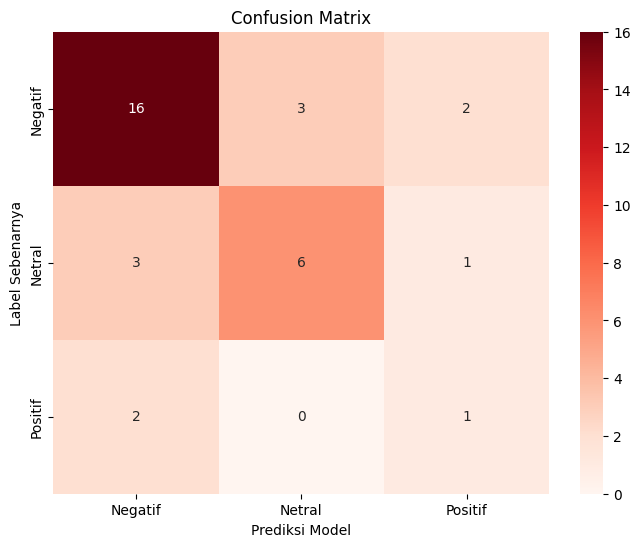

In [ ]:
# Menghitung hasil evaluasi
eval_results = trainer.evaluate()
print("\n=== SKOR EVALUASI AKHIR ===")
print(f"Accuracy  : {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score  : {eval_results['eval_f1']:.4f}")
print(f"Precision : {eval_results['eval_precision']:.4f}")
print(f"Recall    : {eval_results['eval_recall']:.4f}")

# Prediksi data pengujian untuk Confusion Matrix
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Menghitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi Confusion Matrix dengan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix')
plt.show()
